   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

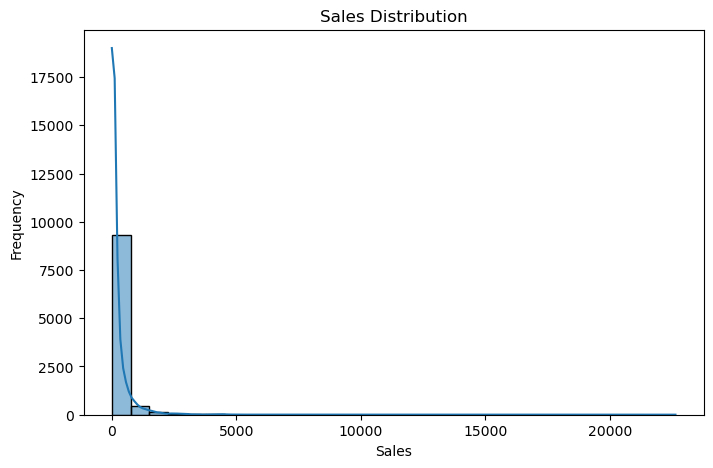

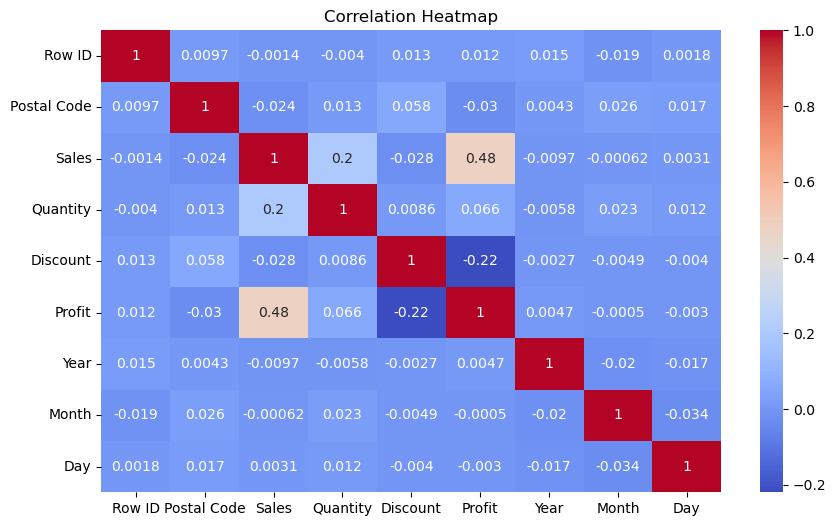

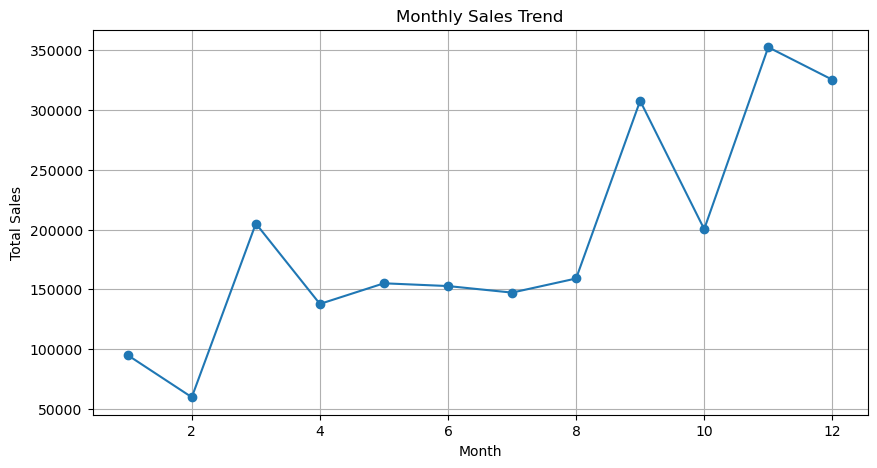

[222.15200302 231.67009193 227.82680835 234.22477103 224.40383038]
Mean Absolute Error: 285.5103717272842
Mean Squared Error: 591300.3507397535
Root Mean Squared Error: 768.9605651395613


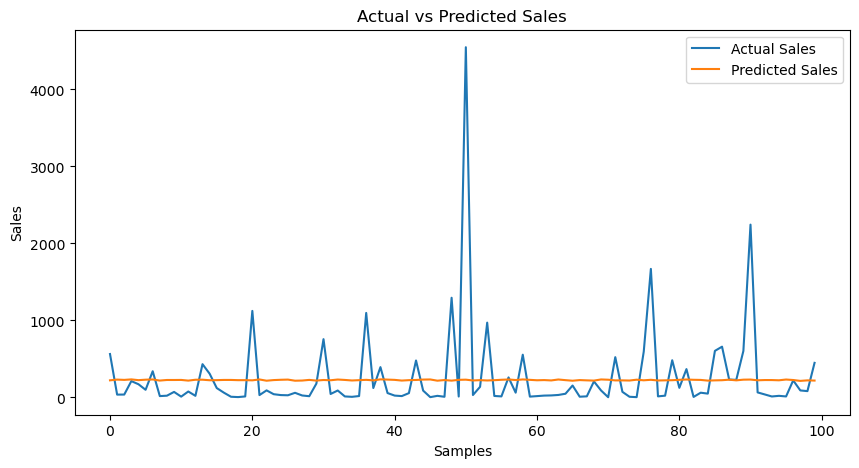

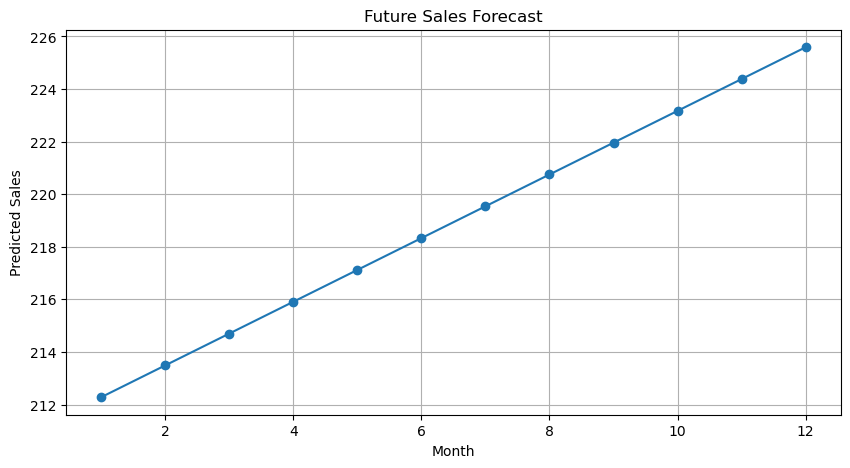

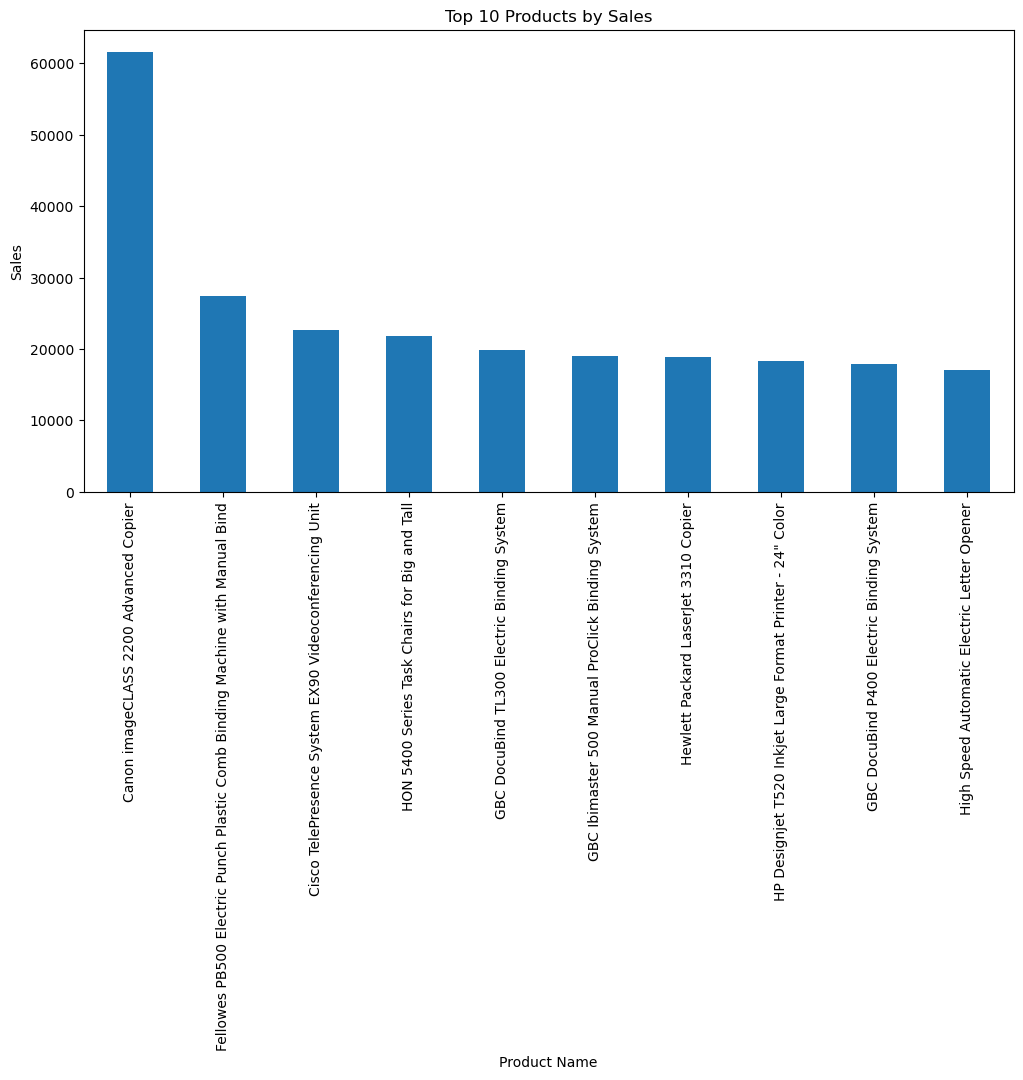

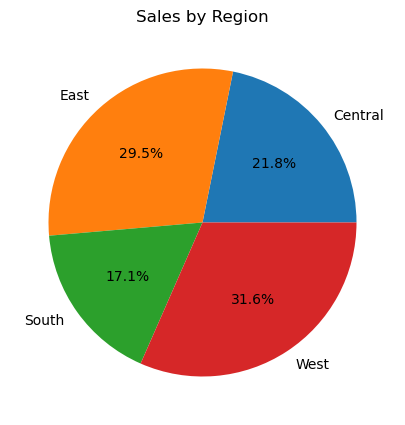


BUSINESS INSIGHTS

1. Sales vary across different months.
2. Some products generate significantly higher revenue.
3. Forecasting helps businesses plan inventory better.
4. Machine learning improves sales prediction accuracy.
5. Regional analysis helps identify high-performing markets.



In [20]:
# ==========================================
# SALES & DEMAND FORECASTING PROJECT
# FUTURE INTERNS - TASK 1
# ==========================================

# ------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# ------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------

df = pd.read_csv(
    "dataset.csv",
    encoding='latin1'
)

# Display first 5 rows
print(df.head())

# Display column names
print(df.columns)

# ------------------------------------------
# 3. DATA CLEANING
# ------------------------------------------

# Remove missing values
df.dropna(inplace=True)

# Convert Order Date column to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create new time-based columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

# Display updated dataframe
print(df.head())

# ------------------------------------------
# 4. SALES DISTRIBUTION GRAPH
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=30, kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

# ------------------------------------------
# 5. CORRELATION HEATMAP
# ------------------------------------------

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# ------------------------------------------
# 6. MONTHLY SALES TREND
# ------------------------------------------

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

# ------------------------------------------
# 7. FEATURE SELECTION
# ------------------------------------------

X = df[['Year', 'Month', 'Day']]
y = df['Sales']

# ------------------------------------------
# 8. TRAIN TEST SPLIT
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# 9. TRAIN MODEL
# ------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)

# ------------------------------------------
# 10. MAKE PREDICTIONS
# ------------------------------------------

predictions = model.predict(X_test)

print(predictions[:5])

# ------------------------------------------
# 11. MODEL EVALUATION
# ------------------------------------------

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

# ------------------------------------------
# 12. ACTUAL VS PREDICTED GRAPH
# ------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:100],
    label='Actual Sales'
)

plt.plot(
    predictions[:100],
    label='Predicted Sales'
)

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.xlabel("Samples")
plt.ylabel("Sales")

plt.show()

# ------------------------------------------
# 13. FUTURE SALES FORECAST
# ------------------------------------------

future_dates = pd.DataFrame({
    'Year': [2026]*12,
    'Month': list(range(1,13)),
    'Day': [1]*12
})

future_predictions = model.predict(future_dates)

plt.figure(figsize=(10,5))

plt.plot(
    future_dates['Month'],
    future_predictions,
    marker='o'
)

plt.title("Future Sales Forecast")

plt.xlabel("Month")
plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()

# ------------------------------------------
# 14. TOP 10 PRODUCTS BY SALES
# ------------------------------------------

top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")

plt.xlabel("Product Name")
plt.ylabel("Sales")

plt.show()

# ------------------------------------------
# 15. SALES BY REGION
# ------------------------------------------

region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Sales by Region")

plt.ylabel("")

plt.show()

# ------------------------------------------
# 16. BUSINESS INSIGHTS
# ------------------------------------------

print("""
BUSINESS INSIGHTS

1. Sales vary across different months.
2. Some products generate significantly higher revenue.
3. Forecasting helps businesses plan inventory better.
4. Machine learning improves sales prediction accuracy.
5. Regional analysis helps identify high-performing markets.
""")